데이터 수집 중...


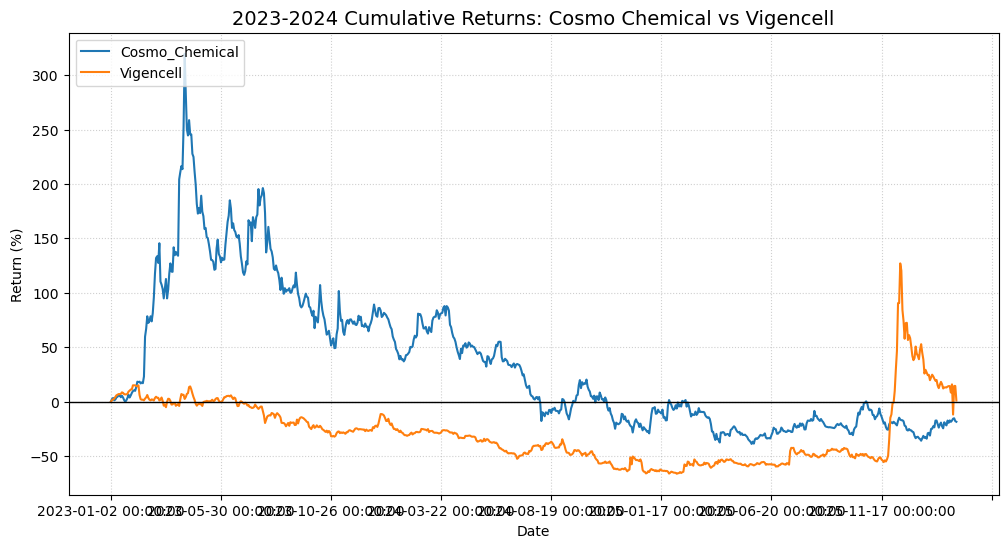


[최종 누적 수익률 현황]
Name
Cosmo_Chemical   -18.551388
Vigencell          1.005747
Name: 2026-02-27 00:00:00, dtype: float64


In [6]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sqlite3

stocks = {'Cosmo_Chemical': '005420', 'Vigencell': '308080'}
df_list = []

print("데이터 수집 중...")
for name, code in stocks.items():
    df = fdr.DataReader(code, '2023-01-01')
    df['Name'] = name
    df_list.append(df)

full_df = pd.concat(df_list)

conn = sqlite3.connect('quant_studdy.db')
full_df.to_sql('daily_prices', conn, if_exists='replace')

query = "SELECT * FROM daily_prices ORDER BY Date ASC"
db_data = pd.read_sql(query, conn)
conn.close()

df_pivot = db_data.pivot(index='Date', columns='Name', values='Close')

daily_return = df_pivot.pct_change().fillna(0)

cum_return = (1+daily_return).cumprod() - 1

plt.figure(figsize=(12, 6))
(cum_return*100).plot(ax=plt.gca())

plt.title('2023-2024 Cumulative Returns: Cosmo Chemical vs Vigencell', fontsize=14)
plt.ylabel('Return (%)')
plt.xlabel('Date')
plt.grid(True, linestyle=':', alpha=0.6)
plt.axhline(0, color='black', lw=1)
plt.legend(loc='upper left')
plt.show()

print("\n[최종 누적 수익률 현황]")
print(cum_return.iloc[-1]*100)

In [8]:
import OpenDartReader
import pandas as pd

# 1. 발급받은 인증키 입력
api_key = '093f9aab97d7b8288d26398f3499c65dce417401'
dart = OpenDartReader(api_key)

# 2. 삼성전자(005930)의 2023년 사업보고서 재무제표 가져오기
# '11011'은 사업보고서를 뜻하는 코드입니다.
report = dart.finstate('005930', 2023, reprt_code='11011')

# 3. 주요 항목만 필터링 (매출액, 영업이익, 당기순이익)
# 'fs_nm'은 연결/개별 구분, 'account_nm'은 계정 이름입니다.
summary = report[report['account_nm'].isin(['매출액', '영업이익', '당기순이익'])]

# 필요한 정보(계정명, 당기금액, 전기금액)만 보기 좋게 출력
print(summary[['account_nm', 'thstrm_amount', 'frmtrm_amount']])

   account_nm        thstrm_amount        frmtrm_amount
9         매출액  258,935,494,000,000  302,231,360,000,000
10       영업이익    6,566,976,000,000   43,376,630,000,000
23        매출액  170,374,090,000,000  211,867,483,000,000
24       영업이익  -11,526,297,000,000   25,319,329,000,000


              Open    High     Low   Close   Volume    Change
Date                                                         
2023-01-02  154000  161000  154000  157000  1132256  0.039735
2023-01-03  158500  160500  156000  159000   787752  0.012739
2023-01-04  157500  161000  157500  160500   463444  0.009434
2023-01-05  161000  161500  158000  159000   577152 -0.009346
2023-01-06  157500  161500  157500  159500   502420  0.003145


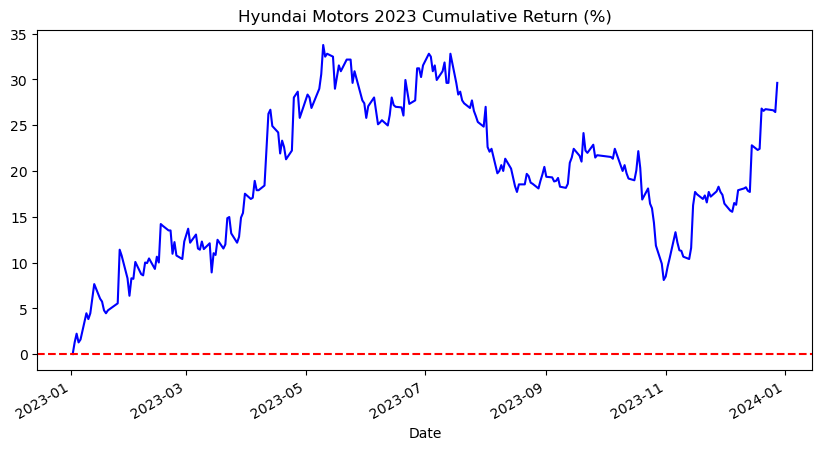

현대차의 2023 최종 수적 수익률은29.62% 입니다.


In [23]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

df = fdr.DataReader('005380', '2023-01-01', '2023-12-31')

print(df.head())

df['Daily_Return'] = df['Close'].pct_change().fillna(0)

df['Cum_Return'] = (1+df['Daily_Return']).cumprod() - 1

(df['Cum_Return']*100).plot(figsize=(10,5), color='blue', title='Hyundai Motors 2023 Cumulative Return (%)')
plt.axhline(0, color='red',linestyle='--')
plt.show()

Final_Return = df['Cum_Return'].iloc[-1]*100

print(f"현대차의 2023 최종 수적 수익률은{Final_Return:.2f}% 입니다.")

In [24]:
import FinanceDataReader as fdr

tickers = ['005420','999999','308080']
data_list = []

print("데이터 수집 시작...")

for code in tickers:
    try:
        df = fdr.DataReader(code,'2024-01-01')
        if df.empty:
            raise Exception("데이터가 비어있습니다.")

        print(f"[{code}] 수집 완료")
        data_list.append(df)

    except Exception as e:
        print(f"[{code}] 수집 실패! 이유: {e}")

print(f"\n총{len(data_list)}개의 종목 데이터를 안전하게 확보했습니다.")

데이터 수집 시작...
[005420] 수집 완료
"999999" invalid symbol or has no data
[999999] 수집 실패! 이유: 데이터가 비어있습니다.
[308080] 수집 완료

총2개의 종목 데이터를 안전하게 확보했습니다.


In [31]:
import FinanceDataReader as fdr

df = fdr.DataReader('035720', '2023-01-01', '2023-12-31')

first_day_close = df.loc['2023-01-02', 'Close']
print(f"2023년 첫날 종가: {first_day_close}")

target_price = first_day_close*1.1
print(f"나의 목표가는 {target_price:,.0f}원 입니다.")

hit_target = df[df['High']>=target_price]

print(f"목표가에 도달했던 날은 총 {len(hit_target)}일 입니다.")
print(hit_target.head())

max_price = df['High'].max()

best_day = df[df['High'] == max_price]

print(f"2023년 카카오의 최고가는 {max_price:,.0f}원이었습니다.")
print(f"그날은 바로 이 날입니다.")
print(best_day.index[0])

2023년 첫날 종가: 52700.0
나의 목표가는 57,970원 입니다.
목표가에 도달했던 날은 총 85일 입니다.
             Open   High    Low  Close   Volume    Change
Date                                                     
2023-01-05  55800  58200  55700  57700  3046064  0.035907
2023-01-06  57200  58000  56500  57200  1420345 -0.008666
2023-01-09  58700  61200  58300  61100  3482961  0.068182
2023-01-10  60700  61700  60400  60700  2178323 -0.006547
2023-01-11  61700  62500  60800  61900  2544430  0.019769
2023년 카카오의 최고가는 71,300원이었습니다.
그날은 바로 이 날입니다.
2023-02-09 00:00:00


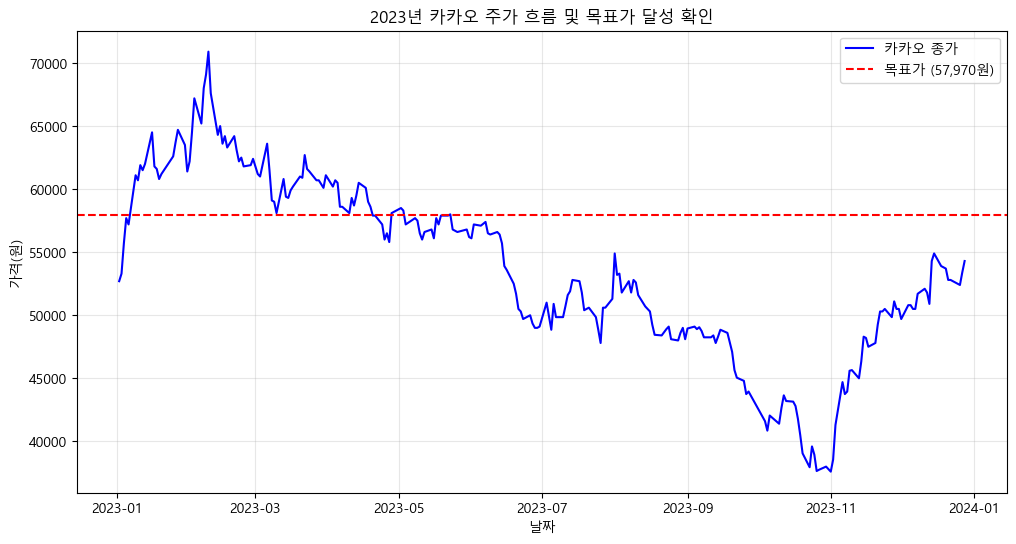

In [36]:
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12,6))

plt.plot(df.index, df['Close'], label='카카오 종가', color='blue')

plt.axhline(y=target_price, color='red', linestyle='--', label=f'목표가 ({target_price:,.0f}원)')

plt.title('2023년 카카오 주가 흐름 및 목표가 달성 확인')
plt.xlabel('날짜')
plt.ylabel('가격(원)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [49]:
import FinanceDataReader as fdr

class StockAnalyzer:
    def __init__(self, code, name):
        self.code = code
        self.name = name
        self.df = None

    def fetch_data(self, start_date):
        print(f"[{self.name}] 데이터를 가져오는 중...")
        self.df = fdr.DataReader(self.code, start_date)
        print(f"[{self.name}] 수집 완료! (데이터 수: {len(self.df)}개)")

    def check_target(self, target_price):
        if self.df is None:
            print("먼저 fetch_data()를 실행해주세요.")
            return

        hit_days = self.df[self.df['High']>=target_price]
        hit_count = len(hit_days)

        print(f"--- {self.name} 분석 결과 ---")
        print(f"목표가 {target_price:,.0f}원을 넘긴 날은 총 {hit_count}일입니다.")

        if hit_count > 0:
            print(f"최고가: {self.df['High'].max():,.0f}원")

    def get_avg_volume(self):
        return self.df['Volume'].mean()

Samsung = StockAnalyzer('005930', '삼성전자')
Samsung.fetch_data('2024-01-01')
Samsung.check_target(85000)
s_vol = Samsung.get_avg_volume()
print(f"삼성전자 평균 거래량은 {s_vol:,.0f}주 입니다.")

print("\n"+"="*30+"\n")

Kakao = StockAnalyzer('035720', '카카오')
Kakao.fetch_data("2024-01-01")
Kakao.check_target(60000)
k_vol = Kakao.get_avg_volume()
print(f"카카오 평균 거래량은 {k_vol:,.0f}주 입니다.")

print("\n" + "엑셀 파일을 생성하는 중...")

with pd.ExcelWriter('주식데이터_상세.xlsx') as writer:
    Samsung.df.to_excel(writer, sheet_name='삼성전자')
    Kakao.df.to_excel(writer, sheet_name='카카오')

summary_data = {
    '종목명': [Samsung.name, Kakao.name],
    '평균거래량': [s_vol, k_vol],
    '최고가': [Samsung.df['High'].max(), Kakao.df['High'].max()]
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_excel('분석요약_리포트.xlsx', index=False)

print("모든 분석 결과가 엑셀 파일로 저장되었습니다.")

[삼성전자] 데이터를 가져오는 중...
[삼성전자] 수집 완료! (데이터 수: 525개)
--- 삼성전자 분석 결과 ---
목표가 85,000원을 넘긴 날은 총 120일입니다.
최고가: 223,000원
삼성전자 평균 거래량은 21,358,574주 입니다.


[카카오] 데이터를 가져오는 중...
[카카오] 수집 완료! (데이터 수: 525개)
--- 카카오 분석 결과 ---
목표가 60,000원을 넘긴 날은 총 115일입니다.
최고가: 71,600원
카카오 평균 거래량은 2,531,642주 입니다.

엑셀 파일을 생성하는 중...
모든 분석 결과가 엑셀 파일로 저장되었습니다.


In [1]:
import os
print(f"현재 파일이 저장되는 경로는: {os.getcwd()} 입니다.")

현재 파일이 저장되는 경로는: C:\Users\L\Desktop\quant_study\Quant-Python-Study 입니다.
